<a href="https://colab.research.google.com/github/Aysha2004/S7_INTERNSHIP/blob/main/S7_Internship_d7_practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import kagglehub

path = kagglehub.dataset_download("jp797498e/twitter-entity-sentiment-analysis")

print("Path to dataset files:",path)

Using Colab cache for faster access to the 'twitter-entity-sentiment-analysis' dataset.
Path to dataset files: /kaggle/input/twitter-entity-sentiment-analysis


In [9]:
import pandas as pd
import os

kaggle_data_path = path # Store the original read-only path

# Define a writable output path and create it
output_data_path = "/tmp/data/"
os.makedirs(output_data_path, exist_ok=True)

print("Files in Kaggle dataset folder:", os.listdir(kaggle_data_path))

# Convert each file to CSV and save to the writable path
for file in os.listdir(kaggle_data_path):
    file_path = os.path.join(kaggle_data_path, file)

    if file.endswith((".txt", ".tsv")):
        df = pd.read_csv(file_path, sep="\t")
    elif file.endswith(".csv"):
        df = pd.read_csv(file_path)
    else:
        continue

    output_file = os.path.join(output_data_path, os.path.splitext(file)[0] + "_converted.csv")

    df.to_csv(output_file, index=False)
    print(f"Saved: {output_file}")

# Update the 'path' variable to point to the writable directory for subsequent cells
path = output_data_path
print("Updated 'path' variable to:", path)

Files in Kaggle dataset folder: ['twitter_validation.csv', 'twitter_training.csv']
Saved: /tmp/data/twitter_validation_converted.csv
Saved: /tmp/data/twitter_training_converted.csv
Updated 'path' variable to: /tmp/data/


In [21]:
import pandas as pd
import os

train_df = pd.read_csv(os.path.join(path, "twitter_training_converted.csv"), names=["Tweet_ID", "Entity", "Sentiment", "Tweet"])
val_df = pd.read_csv(os.path.join(path, "twitter_validation_converted.csv"), names=["Tweet_ID", "Entity", "Sentiment", "Tweet"])

train_df.head()

,Tweet_ID,Entity,Sentiment,Tweet
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [11]:
val_df.head()

,3364,Facebook,Irrelevant,"I mentioned on Facebook that I was struggling for motivation to go for a run the other day, which has been translated by Tom’s great auntie as ‘Hayley can’t get out of bed’ and told to his grandma, who now thinks I’m a lazy, terrible person 🤣"
0,352,Amazon,Neutral,BBC News - Amazon boss Jeff Bezos rejects clai...
1,8312,Microsoft,Negative,@Microsoft Why do I pay for WORD when it funct...
2,4371,CS-GO,Negative,"CSGO matchmaking is so full of closet hacking,..."
3,4433,Google,Neutral,Now the President is slapping Americans in the...
4,6273,FIFA,Negative,Hi @EAHelp I’ve had Madeleine McCann in my cel...


In [22]:
print(train_df.head())
print(train_df.info())

print("\nMissing values:")
print(train_df.isnull().sum())

   Tweet_ID       Entity Sentiment  \
0      2401  Borderlands  Positive   
1      2401  Borderlands  Positive   
2      2401  Borderlands  Positive   
3      2401  Borderlands  Positive   
4      2401  Borderlands  Positive   

                                               Tweet  
0  im getting on borderlands and i will murder yo...  
1  I am coming to the borders and I will kill you...  
2  im getting on borderlands and i will kill you ...  
3  im coming on borderlands and i will murder you...  
4  im getting on borderlands 2 and i will murder ...  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74682 entries, 0 to 74681
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Tweet_ID   74682 non-null  int64 
 1   Entity     74682 non-null  object
 2   Sentiment  74682 non-null  object
 3   Tweet      73996 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB
None

Missing values:
Tweet_ID       0
Entity    

In [15]:
train_df = train_df.dropna()
val_df = val_df.dropna()

print(train_df.shape)
print(val_df.shape)

(73995, 4)
(999, 4)


In [19]:
import re

def clean_text(text):
    text = str(text).lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)

    # Remove mentions
    text = re.sub(r'@\w+', '', text)

    # Remove hashtag symbol
    text = re.sub(r'#', '', text)

    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [23]:
train_df['Clean_Tweet'] = train_df['Tweet'].apply(clean_text)
val_df['Clean_Tweet'] = val_df['Tweet'].apply(clean_text)
train_df[["Tweet", "Clean_Tweet"]].head(10)

,Tweet,Clean_Tweet
0,im getting on borderlands and i will murder yo...,im getting on borderlands and i will murder yo...
1,I am coming to the borders and I will kill you...,i am coming to the borders and i will kill you...
2,im getting on borderlands and i will kill you ...,im getting on borderlands and i will kill you all
3,im coming on borderlands and i will murder you...,im coming on borderlands and i will murder you...
4,im getting on borderlands 2 and i will murder ...,im getting on borderlands and i will murder yo...
5,im getting into borderlands and i can murder y...,im getting into borderlands and i can murder y...
6,So I spent a few hours making something for fu...,so i spent a few hours making something for fu...
7,So I spent a couple of hours doing something f...,so i spent a couple of hours doing something f...
8,So I spent a few hours doing something for fun...,so i spent a few hours doing something for fun...
9,So I spent a few hours making something for fu...,so i spent a few hours making something for fu...


Training Dataset Shape: (74682, 5)
Validation Dataset Shape: (1000, 4)

Columns:
Index(['Tweet_ID', 'Entity', 'Sentiment', 'Tweet', 'Tweet_Length'], dtype='object')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74682 entries, 0 to 74681
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Tweet_ID      74682 non-null  int64 
 1   Entity        74682 non-null  object
 2   Sentiment     74682 non-null  int64 
 3   Tweet         73996 non-null  object
 4   Tweet_Length  74682 non-null  int64 
dtypes: int64(3), object(2)
memory usage: 2.8+ MB
None

Missing Values:
Tweet_ID          0
Entity            0
Sentiment         0
Tweet           686
Tweet_Length      0
dtype: int64

Duplicate Rows:
2700

First 5 Rows:
   Tweet_ID       Entity  Sentiment  \
0      2401  Borderlands          3   
1      2401  Borderlands          3   
2      2401  Borderlands          3   
3      2401  Borderlands          3   
4

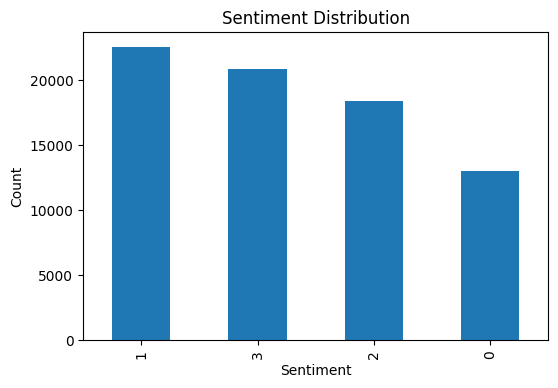


Tweet Length Statistics:
count    74682.000000
mean       107.811963
std         79.798839
min          1.000000
25%         45.000000
50%         90.000000
75%        152.000000
max        957.000000
Name: Tweet_Length, dtype: float64


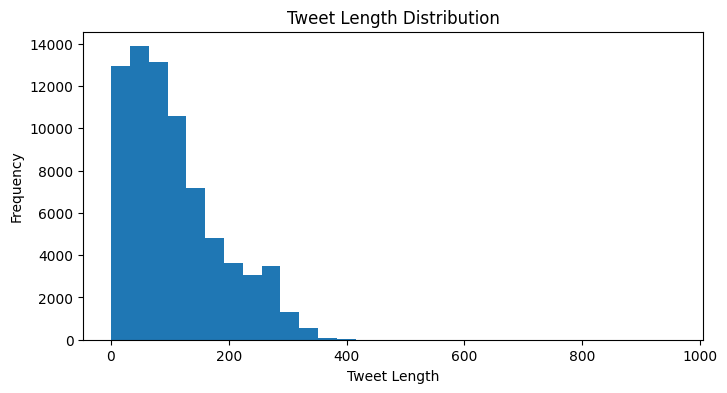


Top 10 Entities:
Entity
Microsoft                    2400
MaddenNFL                    2400
TomClancysRainbowSix         2400
LeagueOfLegends              2394
CallOfDuty                   2394
Verizon                      2382
CallOfDutyBlackopsColdWar    2376
ApexLegends                  2376
Facebook                     2370
WorldOfCraft                 2364
Name: count, dtype: int64


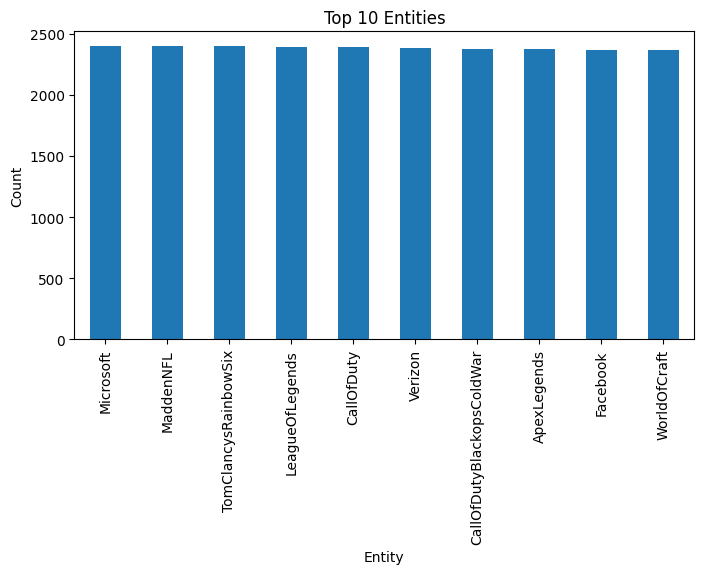

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import os


# Basic Information
print("Training Dataset Shape:", train_df.shape)
print("Validation Dataset Shape:", val_df.shape)

print("\nColumns:")
print(train_df.columns)

print("\nDataset Info:")
print(train_df.info())

# Missing Values
print("\nMissing Values:")
print(train_df.isnull().sum())


# Duplicate Records
print("\nDuplicate Rows:")
print(train_df.duplicated().sum())

# First 5 Records
print("\nFirst 5 Rows:")
print(train_df.head())

# Sentiment Distribution
print("\nSentiment Distribution:")
print(train_df["Sentiment"].value_counts())

# Plot sentiment distribution
plt.figure(figsize=(6,4))
train_df["Sentiment"].value_counts().plot(kind="bar")
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()


# Tweet Length Analysis
train_df["Tweet_Length"] = train_df["Tweet"].astype(str).apply(len)

print("\nTweet Length Statistics:")
print(train_df["Tweet_Length"].describe())

plt.figure(figsize=(8,4))
plt.hist(train_df["Tweet_Length"], bins=30)
plt.title("Tweet Length Distribution")
plt.xlabel("Tweet Length")
plt.ylabel("Frequency")
plt.show()

# Top Entities
print("\nTop 10 Entities:")
print(train_df["Entity"].value_counts().head(10))

plt.figure(figsize=(8,4))
train_df["Entity"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Entities")
plt.xlabel("Entity")
plt.ylabel("Count")
plt.show()

In [25]:
from sklearn.preprocessing import LabelEncoder

# Create encoder
le = LabelEncoder()

# Fit on training labels and transform
train_df["Sentiment"] = le.fit_transform(train_df["Sentiment"])

# Transform validation labels using same encoder
val_df["Sentiment"] = le.transform(val_df["Sentiment"])

In [26]:
print(dict(zip(le.classes_, le.transform(le.classes_))))

{'Irrelevant': np.int64(0), 'Negative': np.int64(1), 'Neutral': np.int64(2), 'Positive': np.int64(3)}


In [27]:
train_df[["Sentiment"]].head()

,Sentiment
0,3
1,3
2,3
3,3
4,3


In [28]:
train_df["Sentiment"].value_counts()

,count
Sentiment,
1,22542
3,20832
2,18318
0,12990


In [31]:
# Ensure 'Clean_Tweet' column exists before proceeding
if 'Clean_Tweet' not in train_df.columns:
    train_df['Clean_Tweet'] = train_df['Tweet'].astype(str).apply(clean_text)
if 'Clean_Tweet' not in val_df.columns:
    val_df['Clean_Tweet'] = val_df['Tweet'].astype(str).apply(clean_text)

X_train_text = train_df["Clean_Tweet"]
X_val_text = val_df["Clean_Tweet"]

y_train = train_df["Sentiment"]
y_val = val_df["Sentiment"]

In [32]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words='english'
)

X_train = tfidf.fit_transform(X_train_text)
X_val = tfidf.transform(X_val_text)

In [33]:
print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)

print("y_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)

X_train shape: (74682, 5000)
X_val shape: (1000, 5000)
y_train shape: (74682,)
y_val shape: (1000,)


In [34]:
from sklearn.model_selection import train_test_split

X = train_df["Clean_Tweet"]
y = train_df["Sentiment"]

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [35]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words='english'
)

X_train = tfidf.fit_transform(X_train_text)
X_test = tfidf.transform(X_test_text)

In [36]:
print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(59745, 5000)
(14937, 5000)
(59745,)
(14937,)


In [37]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


In [38]:
y_pred_lr = lr_model.predict(X_test)

In [52]:
from sklearn.metrics import accuracy_score

lr_accuracy = accuracy_score(y_test, y_pred_lr)

print("Accuracy:", lr_accuracy)

Accuracy: 0.6768427395059249


In [40]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.69      0.50      0.58      2598
           1       0.68      0.79      0.73      4509
           2       0.65      0.62      0.64      3664
           3       0.69      0.72      0.70      4166

    accuracy                           0.68     14937
   macro avg       0.68      0.66      0.66     14937
weighted avg       0.68      0.68      0.67     14937



In [41]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_lr)

print(cm)

[[1295  511  321  471]
 [ 161 3547  436  365]
 [ 230  639 2262  533]
 [ 185  538  437 3006]]


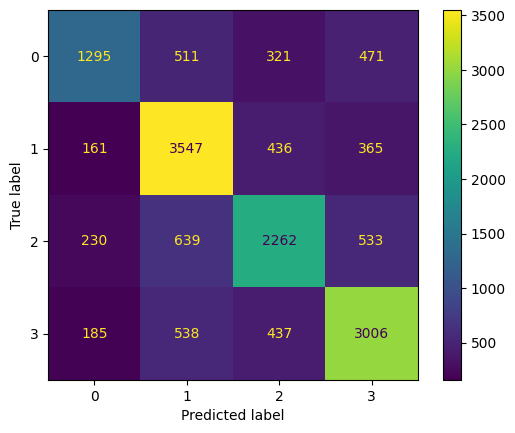

In [42]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr)

plt.show()


In [43]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC()

svm_model.fit(X_train, y_train)

LinearSVC()

In [45]:
y_pred_svm = svm_model.predict(X_test)

In [46]:
from sklearn.metrics import accuracy_score

svm_accuracy = accuracy_score(y_test, y_pred_svm)

print("SVM Accuracy:", svm_accuracy)

SVM Accuracy: 0.6953872932985204


In [47]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [48]:
y_pred_rf = rf_model.predict(X_test)

In [49]:
from sklearn.metrics import accuracy_score

rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.8584722501171588


In [50]:
sample_tweet = ["This game is amazing and I love it"]

sample_vec = tfidf.transform(sample_tweet)

prediction = rf_model.predict(sample_vec)

print("Predicted Label:", prediction[0])

print("Predicted Sentiment:", le.inverse_transform(prediction)[0])

Predicted Label: 3
Predicted Sentiment: Positive


In [53]:
models = {
    "Logistic Regression": lr_accuracy,
    "SVM": svm_accuracy,
    "Random Forest": rf_accuracy
}

best_model_name = max(models, key=models.get)
best_accuracy = models[best_model_name]

print(f"Best Model: {best_model_name}")
print(f"Accuracy: {best_accuracy:.4f}")

Best Model: Random Forest
Accuracy: 0.8585


In [54]:
tweet = input("Enter a tweet: ")

# Transform using the fitted TF-IDF vectorizer
tweet_tfidf = tfidf.transform([tweet])

# Predict using your best model (e.g., SVM)
prediction = rf_model.predict(tweet_tfidf)

# Convert label back to sentiment
sentiment = le.inverse_transform(prediction)

print("Predicted Sentiment:", sentiment[0])

Enter a tweet: i love this movie
Predicted Sentiment: Positive
